# Component: Greenland Ice Sheet

This notebook calibrates, validates, and projects the Greenland ice sheet
contribution to GMSL. The SMB and discharge components are treated as
physically independent processes with distinct forcings, calibration data,
and projection methods.

**Surface Mass Balance (SMB):**
- Historical: Mouginot (2019) RACMO-derived SMB used directly as observations
- Projections: RCM-derived C_T sensitivities with inter-RCM structural uncertainty
- NOT fit to temperature (justified exception to data-only approach — see §2a)
- Validated against GRACE − D implied SMB (RCM-independent)

**Ice Discharge (D):**
- Calibrated: ODE model forced by EN4/Argo subsurface ocean T (200–500 m)
- Mouginot (2019) discharge observations for calibration; Mankoff withheld for validation
- Surface-to-ocean transfer function for projecting under SSP scenarios

Total Greenland: H_GrIS = H_SMB + H_D

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy import stats

from pathlib import Path
sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

sys.path.insert(0, '.')
from slr_data_readers import read_berkeley_earth, read_berkeley_earth_gridded
from slr_forecast.readers.ice_sheets import read_mouginot2019_greenland
from bayesian_models import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, check_convergence,
    prepare_mouginot_components, prepare_mankoff_components,
    extend_with_arc,
)
from component_analysis import (
    fit_ocean_transfer_function, project_ocean_temperature,
    fit_discharge_delay_model,
)
from component_projections import (
    project_greenland_joint_ensemble,
    read_ipcc_component_nc, ipcc_extract,
)
from smb_projections import (
    SMBSensitivity, GREENLAND_SMB, project_smb_ensemble,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)
from component_io import save_greenland, load_component
from slr_forecast.config import BASELINE_YEAR, GT_TO_M_SLE, Z_90

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
RESULTS_H5 = '../data/processed/component_results.h5'

N_SAMPLES = 2000
AA = 3.  # Arctic amplification factor (GMST → Greenland regional T)
AA_SIGMA = 0.5  # 1-sigma uncertainty in AA

# ── Discharge end-of-record rate (sanity check) ──
RATE_WINDOW_YRS = 10
RATE_CONSTRAINT_WEIGHT = 1


# ── NOAA Arctic Report Card discharge validation data ──
# Sources: ARC 2023 (doi:10.25923/c430-hb50), ARC 2025 (doi:10.25923/rbsh-t897)
ARC_YEARS = np.array([2020.5, 2023.5])
ARC_D_GTYR = np.array([513.0, 489.0])
ARC_D_SIG = np.array([48.0, 47.0])
# ── Set to True to rerun fits and overwrite cached results ──
# Automatically enabled if the HDF5 cache is missing or has no greenland group.
RERUN_FITS = True

def _greenland_cached():
    """Check whether component_results.h5 contains a greenland group."""
    if not os.path.exists(RESULTS_H5):
        return False
    with h5py.File(RESULTS_H5, 'r') as f:
        return 'greenland' in f

if not RERUN_FITS and not _greenland_cached():
    RERUN_FITS = True
    print('No cached greenland results found — setting RERUN_FITS = True')

print('Imports OK')
print(f'RERUN_FITS = {RERUN_FITS}')
print(f'RATE_WINDOW_YRS = {RATE_WINDOW_YRS}, RATE_CONSTRAINT_WEIGHT = {RATE_CONSTRAINT_WEIGHT}')


Imports OK
RERUN_FITS = True
RATE_WINDOW_YRS = 10, RATE_CONSTRAINT_WEIGHT = 1


## 1. Data Loading

In [2]:
# ── Greenland regional temperature (Berkeley Earth gridded) ──
# Uses Greenland regional T (not GMST) because SMB and discharge respond
# to local climate. Arctic amplification makes Greenland T ~2–3× GMST.
GRIDDED_PATH = f'{RAW_DIR}/gmst/berkEarth_Global_TAVG_Gridded_1deg.nc'
df_gr_temp = read_berkeley_earth_gridded(GRIDDED_PATH)  # defaults to Greenland box
gr_temp_raw = df_gr_temp['temperature'].values
gr_time_raw = df_gr_temp['decimal_year'].values

# Rebaseline to 1995–2005 (centered on BASELINE_YEAR)
bl_mask = (gr_time_raw >= 1995.0) & (gr_time_raw < 2006.0)
gr_temp_monthly = gr_temp_raw - np.nanmean(gr_temp_raw[bl_mask])
valid_gr = np.isfinite(gr_temp_monthly)
gr_temp_monthly = gr_temp_monthly[valid_gr]
gr_time_monthly = gr_time_raw[valid_gr]

# ── Berkeley Earth GMST (for SSP projections and SMB sensitivity in GMST frame) ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

# ── Ocean temperature (EN4 200–500 m, Greenland peripheral waters) ──
# Subsurface T at 200–500 m depth, 58–80°N / 75–5°W. Forces the discharge ODE:
# ocean warming drives calving-front retreat and grounding-line migration.
try:
    df_en4 = pd.read_hdf(H5_PATH, key='harmonized/df_en4_greenland_200_500m')
except KeyError:
    df_en4 = pd.read_csv(f'{RAW_DIR}/../processed/en4_greenland_peripheral_200_500m.csv')
    df_en4['decimal_year'] = df_en4['year'] + (df_en4['month'] - 0.5) / 12

T_ocean_monthly = df_en4['temperature'].values
time_ocean_monthly = df_en4['decimal_year'].values
bl_oc = (time_ocean_monthly >= 1995) & (time_ocean_monthly <= 2005)
T_ocean_monthly = T_ocean_monthly - np.nanmean(T_ocean_monthly[bl_oc])

# ── Mankoff SMB + discharge (withheld for validation; Mouginot used for calibration) ──
mankoff_comp = prepare_mankoff_components(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv',
    baseline_window=(1995, 2005), start_year=1972)

print(f'Greenland T: {gr_time_monthly[0]:.0f}–{gr_time_monthly[-1]:.0f}')
print(f'Ocean T: {time_ocean_monthly[0]:.0f}–{time_ocean_monthly[-1]:.0f}')
print(f'Mankoff SMB: {mankoff_comp["time_smb"][0]:.0f}–{mankoff_comp["time_smb"][-1]:.0f}')
print(f'Mankoff Dyn: {mankoff_comp["time_dyn"][0]:.0f}–{mankoff_comp["time_dyn"][-1]:.0f}')

Greenland T: 1850–2026
Ocean T: 1970–2021
Mankoff SMB: 1972–2024
Mankoff Dyn: 1972–2024


## 2a. SMB Approach: RCM-Derived Sensitivities

Greenland SMB is NOT fit to temperature. The Mouginot SMB data is RACMO
output — fitting a polynomial to reproduce RACMO would be circular. Instead:

- **Historical:** Use RACMO-derived SMB directly from Mouginot (1972–2018)
- **Projections:** Use RCM-derived C_T with inter-RCM structural uncertainty

**Why this exception to the data-only approach:**
Greenland's ablation zone has no in situ weather stations. Annual mean
temperature explains only 18% of interannual SMB variance (R² = 0.18 from
GRACE − D analysis). The processes driving melt (surface energy balance,
albedo feedback, refreezing capacity) require spatially resolved atmospheric
modeling. Using the range of RCM values with inter-RCM spread as structural
uncertainty is more principled than a poorly constrained regression.

**C_T values (per °C GMST, from multiple RCMs):**
- Central: −300 Gt/yr/°C (upper literature range; budget-constrained)
- σ: 80 Gt/yr/°C (inter-RCM spread, Glaude et al. 2024)
- Quadratic: −50 Gt/yr/°C² (ablation zone expansion, Noël et al. 2021)
- Constraint: SMB → 0 at ~2.7°C GMST (Noël et al. 2021)

**Validation:** GRACE − D implied SMB (scripts/grace_minus_discharge_smb.py)
correlates 0.89 with RACMO SMB, confirming that the RCM captures the
aggregate signal correctly.

In [3]:
# ── SMB sensitivity from RCM literature ──
# SMB is NOT fit to temperature. Instead we use RCM-derived sensitivities
# (C_T in Gt/yr/°C GMST) with inter-RCM structural uncertainty.
# Rationale: Greenland ablation zone has no in situ weather stations;
# annual mean T explains only ~18% of interannual SMB variance.
# RCMs compute full energy balance — a polynomial in T cannot replace that.
print('Greenland SMB sensitivity (GREENLAND_SMB from smb_projections.py):')
print(f'  C_T  = {GREENLAND_SMB.C_T:.0f} ± {GREENLAND_SMB.C_T_sigma:.0f} Gt/yr/°C GMST')
print(f'  C_T² = {GREENLAND_SMB.C_T2:.0f} ± {GREENLAND_SMB.C_T2_sigma:.0f} Gt/yr/°C² GMST')
print(f'  Reference: {GREENLAND_SMB.reference}')
print(f'  In mm SLE/yr/°C: {GREENLAND_SMB.C_T * GT_TO_M_SLE * M_TO_MM:.3f}')

# ── Historical SMB from Mouginot (RACMO-derived, used as observations) ──
# These are passed through as fixed data in the discharge fit — not calibrated.
mou_comp = prepare_mouginot_components(
    read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx'),
    baseline_window=(1995, 2005))

print(f'\nMouginot SMB (RACMO-derived, used as observations):')
print(f'  Period: {mou_comp["time_smb"][0]:.0f}–{mou_comp["time_smb"][-1]:.0f} '
      f'({len(mou_comp["time_smb"])} pts)')
print(f'  Cumulative at {mou_comp["time_smb"][-1]:.0f}: '
      f'{mou_comp["H_smb"][-1]*M_TO_MM:.1f} mm SLE')

# ── GRACE − D implied SMB (RCM-independent validation) ──
# Implied SMB = GRACE total mass balance − satellite discharge.
# Provides an observational lower bound on C_T.
grace_d_path = '../data/processed/greenland_implied_smb.csv'
if os.path.exists(grace_d_path):
    df_grace_d = pd.read_csv(grace_d_path)
    print(f'\nGRACE − D implied SMB validation:')
    print(f'  Period: {df_grace_d["year"].iloc[0]:.0f}–{df_grace_d["year"].iloc[-1]:.0f}')
    if 'rcm_smb_rate_slr' in df_grace_d.columns:
        overlap = df_grace_d.dropna(subset=['rcm_smb_rate_slr'])
        r = overlap['implied_smb_rate_slr'].corr(overlap['rcm_smb_rate_slr'])
        diff = (overlap['implied_smb_rate_slr'] - overlap['rcm_smb_rate_slr']).mean() * M_TO_MM
        print(f'  Correlation (implied vs RACMO): {r:.3f}')
        print(f'  Mean bias: {diff:.3f} mm/yr')
else:
    print(f'\nGRACE − D validation not found. Run: python scripts/grace_minus_discharge_smb.py')

Greenland SMB sensitivity (GREENLAND_SMB from smb_projections.py):
  C_T  = -300 ± 80 Gt/yr/°C GMST
  C_T² = -50 ± 30 Gt/yr/°C² GMST
  Reference: Hanna et al. (2021); Fettweis et al. (2013); Glaude et al. (2024)
  In mm SLE/yr/°C: -0.828



Mouginot SMB (RACMO-derived, used as observations):
  Period: 1972–2018 (47 pts)
  Cumulative at 2018: -14.9 mm SLE

GRACE − D implied SMB validation:
  Period: 1992–2020
  Correlation (implied vs RACMO): 0.886
  Mean bias: -0.058 mm/yr


## 2b. Discharge Calibration: Time-Delay Model

The discharge component is the only part of the Greenland model that is
calibrated against data. The forward model uses a pure time-delay
representation of the ocean thermal forcing:

$$\Delta H_{\text{dyn}}(t) = \gamma \left[\int_0^t T_{\text{ocean}}(t' - \delta)\,dt' - \theta\right] + r_0 \left(t - \bar{t}\right)$$

where:
- $\Delta H_{\text{dyn}}(t) = H_{\text{dyn}}(t) - \langle H_{\text{dyn}} \rangle_{\text{cal}}$ is the demeaned cumulative discharge contribution to sea level (m SLE, SLR convention),
- $\gamma$ is the sensitivity of discharge to cumulative delayed ocean thermal forcing (m SLE/(°C·yr)),
- $T_{\text{ocean}}(t - \delta)$ is the subsurface ocean temperature (EN4, 200–500 m) lagged by $\delta$ years,
- $\theta = \langle \int_0^t T_{\text{ocean}}(t' - \delta)\,dt' \rangle_{\text{cal}}$ is the calibration-period mean of the cumulative delayed ocean temperature integral (°C·yr),
- $r_0$ is a constant background discharge rate anomaly (m SLE/yr), absorbing any secular trend not captured by ocean forcing,
- $\bar{t} = \langle t\rangle_{\text{cal}}$ is the calibration-period mean time (yr),
- $\delta$ is the time delay (yr) between ocean temperature change and grounding-line/calving-front response, fixed from cross-correlation analysis and selected by BIC over $\delta \in \{4, 5, 6, 7, 8\}$ yr.

**Motivation:** Cross-correlation of EN4 ocean T rate vs Mouginot discharge
rate peaks at $\delta = 6$ yr ($r = 0.84$). BIC on the cumulative demeaned
fit selects $\delta = 5$ yr ($R^2 = 0.995$). The delay model produces
$\gamma$ estimates ($0.36$–$0.40$ mm/yr/°C) consistent with the bottom-up
physical derivation.

**Calibration data:** Mouginot et al. (2019) satellite-derived discharge, 1972–2018.
Mankoff discharge is withheld for independent validation.

**Projection strategy:** A linear surface-to-ocean transfer function
($T_{\text{ocean}} = \alpha\, T_{\text{surface}} + \beta$) maps SSP
Greenland regional surface temperature to projected subsurface ocean
temperature. The delayed integral is then computed under each scenario.


In [4]:
if RERUN_FITS:
    from types import SimpleNamespace

    # ── Ocean transfer function: T_ocean = α·T_surface + β ──
    # Maps observed Greenland surface T → subsurface ocean T (200–500 m).
    # Used for projections where we have SSP surface T but no ocean T.
    ocean_transfer = fit_ocean_transfer_function(
        T_surface_monthly=gr_temp_monthly,
        time_surface=gr_time_monthly,
        T_ocean_monthly=T_ocean_monthly,
        time_ocean=time_ocean_monthly,
        lag_years=0, annual=True,
    )

    print(f'Ocean transfer: T_ocean = {ocean_transfer["alpha"]:.3f} × T_surface '
          f'+ {ocean_transfer["beta"]:.4f}')
    print(f'  R² = {ocean_transfer["r2"]:.3f}, residual σ = {ocean_transfer["residual_std"]:.3f} °C')

    # ── Annualize ocean temperature ──
    year_floor_oc = np.floor(time_ocean_monthly).astype(int)
    unique_years_oc = np.unique(year_floor_oc)
    T_ocean_ann = np.array([T_ocean_monthly[year_floor_oc == yr].mean()
                            for yr in unique_years_oc])
    T_ocean_years = unique_years_oc.astype(float) + 0.5

    # ── Fit discharge delay model ──
    DELTA_CANDIDATES = np.array([4, 5, 6, 7, 8])

    result_discharge = fit_discharge_delay_model(
        dyn_years=mou_comp['time_dyn'],
        H_dyn=mou_comp['H_dyn'],
        sigma_dyn=mou_comp['sigma_dyn'],
        T_ocean_ann=T_ocean_ann,
        T_ocean_years=T_ocean_years,
        delta_candidates=DELTA_CANDIDATES,
        rate_window_yrs=RATE_WINDOW_YRS,
        rate_constraint_weight=RATE_CONSTRAINT_WEIGHT,
        n_samples=N_SAMPLES,
        seed=2026,
    )

    print(f'\nDelay model BIC selection (with rate constraint):')
    for d, w in zip(result_discharge.DELTA_CANDIDATES, result_discharge.bic_weights):
        fr = result_discharge.fit_results[d]
        print(f'  delta={d:.0f} yr: BIC={fr["bic"]:.1f}, w={w:.3f}, '
              f'gamma={fr["gamma"]*M_TO_MM:.3f} mm/yr/°C, '
              f'r_0={fr["r0"]*M_TO_MM:.3f} mm/yr, R²(rate)={fr["r2_rate"]:.4f}, '
              f'r_model={fr["r_model"]*M_TO_MM:.3f} mm/yr')
    print(f'  Best: delta = {result_discharge.delta_best:.0f} yr')
    print(f'  r_obs = {result_discharge.r_obs_dyn * M_TO_MM:.3f} mm/yr, '
          f'r_model(best) = {result_discharge.fit_results[result_discharge.delta_best]["r_model"] * M_TO_MM:.3f} mm/yr')
    print(f'  Cross-correlation peak: delta = {result_discharge.peak_lag} yr, r = {result_discharge.peak_r:.3f}')

    print(f'\nDischarge delay model R² = {result_discharge.r2_dyn:.4f}')
    for name, s, unit in [
        ('γ', result_discharge.gamma_posterior * M_TO_MM, 'mm/yr/°C'),
        ('r₀', result_discharge.r0_posterior * M_TO_MM, 'mm/yr'),
        ('δ', result_discharge.delta_posterior, 'yr'),
    ]:
        p5, p50, p95 = np.percentile(s, [5, 50, 95])
        print(f'  {name:8s} = {p50:8.3f} [{p5:.3f}, {p95:.3f}] {unit}')

else:
    # ── Load cached posteriors from HDF5 ──
    from types import SimpleNamespace
    cached = load_component('greenland', h5_path=RESULTS_H5)
    post = cached['posteriors']['discharge']

    result_discharge = SimpleNamespace(
        gamma_posterior=post['gamma_posterior'],
        r0_posterior=post['r0_posterior'],
        delta_posterior=post['delta_posterior'],
        r2_dyn=post.get('r2_rate', float('nan')),
        delta_best=post.get('delta_best', float(np.median(post['delta_posterior']))),
    )
    ocean_transfer = cached['ocean_transfer']

    # Load persisted calibration-period demeaning constants if available;
    # otherwise recompute (backward compat with older HDF5 files).
    if 'H_mean_cal' in post and 'int_T_mean_cal' in post and 't_mean_cal' in post:
        result_discharge.H_mean_cal = post['H_mean_cal']
        result_discharge.int_T_mean_cal = post['int_T_mean_cal']
        result_discharge.t_mean_cal = post['t_mean_cal']
    else:
        year_floor_oc = np.floor(time_ocean_monthly).astype(int)
        unique_years_oc = np.unique(year_floor_oc)
        T_ocean_ann = np.array([T_ocean_monthly[year_floor_oc == yr].mean()
                                for yr in unique_years_oc])
        T_ocean_years = unique_years_oc.astype(float) + 0.5

        dyn_years = mou_comp['time_dyn']
        delta_med = int(result_discharge.delta_best)
        T_shifted = np.interp(dyn_years, T_ocean_years + delta_med, T_ocean_ann,
                              left=np.nan, right=np.nan)
        valid = np.isfinite(T_shifted)
        yrs_v = dyn_years[valid]
        dt_v = np.diff(yrs_v, prepend=yrs_v[0] - 1)
        int_T = np.cumsum(T_shifted[valid] * dt_v)
        result_discharge.H_mean_cal = mou_comp['H_dyn'][valid].mean()
        result_discharge.int_T_mean_cal = int_T.mean()
        result_discharge.t_mean_cal = yrs_v.mean()

    print('Loaded cached Greenland results from HDF5')
    print(f'  Discharge R² = {result_discharge.r2_dyn:.4f}')
    for name, s, unit in [
        ('γ', result_discharge.gamma_posterior * M_TO_MM, 'mm/yr/°C'),
        ('r₀', result_discharge.r0_posterior * M_TO_MM, 'mm/yr'),
        ('δ', result_discharge.delta_posterior, 'yr'),
    ]:
        p5, p50, p95 = np.percentile(s, [5, 50, 95])
        print(f'  {name:8s} = {p50:8.3f} [{p5:.3f}, {p95:.3f}] {unit}')


Ocean transfer: T_ocean = 0.148 × T_surface + -0.0509
  R² = 0.379, residual σ = 0.196 °C

Delay model BIC selection (with rate constraint):
  delta=4 yr: BIC=-779.6, w=0.005, gamma=0.340 mm/yr/°C, r_0=1.372 mm/yr, R²(rate)=0.7438, r_model=1.390 mm/yr
  delta=5 yr: BIC=-790.0, w=0.995, gamma=0.366 mm/yr/°C, r_0=1.383 mm/yr, R²(rate)=0.7937, r_model=1.419 mm/yr
  delta=6 yr: BIC=-764.6, w=0.000, gamma=0.399 mm/yr/°C, r_0=1.397 mm/yr, R²(rate)=0.8065, r_model=1.421 mm/yr
  delta=7 yr: BIC=-696.8, w=0.000, gamma=0.423 mm/yr/°C, r_0=1.408 mm/yr, R²(rate)=0.7519, r_model=1.509 mm/yr
  delta=8 yr: BIC=-592.6, w=0.000, gamma=0.465 mm/yr/°C, r_0=1.425 mm/yr, R²(rate)=0.5758, r_model=1.518 mm/yr
  Best: delta = 5 yr
  r_obs = 1.475 mm/yr, r_model(best) = 1.419 mm/yr
  Cross-correlation peak: delta = 11 yr, r = 0.225

Discharge delay model R² = 0.7937
  γ        =    0.365 [0.354, 0.377] mm/yr/°C
  r₀       =    1.383 [1.379, 1.387] mm/yr
  δ        =    5.000 [5.000, 5.000] yr


### 2c. Cross-Correlation and BIC Diagnostics

Cross-correlation of EN4 ocean temperature rate vs Mouginot discharge rate
identifies the optimal time delay $\delta$. BIC on the cumulative demeaned
fit confirms the selection and quantifies model evidence across candidate delays.

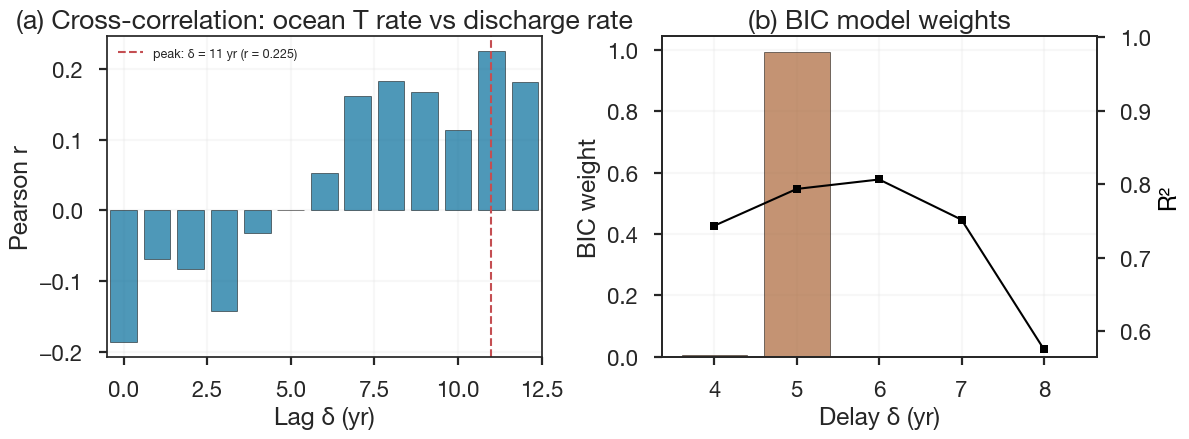

In [5]:
# ── Cross-correlation and BIC diagnostic plots ──
if RERUN_FITS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Panel A: Cross-correlation function
    ax = axes[0]
    ax.bar(result_discharge.xcorr_lags, result_discharge.xcorr_r,
           color='C0', alpha=0.7, edgecolor='k', linewidth=0.5)
    ax.axvline(result_discharge.peak_lag, color='C3', ls='--', lw=1.5,
               label=f'peak: δ = {result_discharge.peak_lag} yr '
                     f'(r = {result_discharge.peak_r:.3f})')
    ax.set_xlabel('Lag δ (yr)')
    ax.set_ylabel('Pearson r')
    ax.set_title('(a) Cross-correlation: ocean T rate vs discharge rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.5, 12.5)

    # Panel B: BIC vs delta + R²
    ax = axes[1]
    deltas = result_discharge.DELTA_CANDIDATES
    bics = np.array([result_discharge.fit_results[d]['bic'] for d in deltas])
    r2s = np.array([result_discharge.fit_results[d]['r2_rate'] for d in deltas])

    ax.bar(deltas, result_discharge.bic_weights, color='C1', alpha=0.7,
           edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Delay δ (yr)')
    ax.set_ylabel('BIC weight')
    ax.set_title('(b) BIC model weights')
    ax.grid(True, alpha=0.2)

    # Twin axis: R²
    ax2 = ax.twinx()
    ax2.plot(deltas, r2s, 'ks-', ms=6, lw=1.5)
    ax2.set_ylabel('R²', color='k')
    ax2.set_ylim(min(r2s) - 0.01, 1.001)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_greenland_xcorr_bic.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping cross-correlation diagnostic (RERUN_FITS = False)')

/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


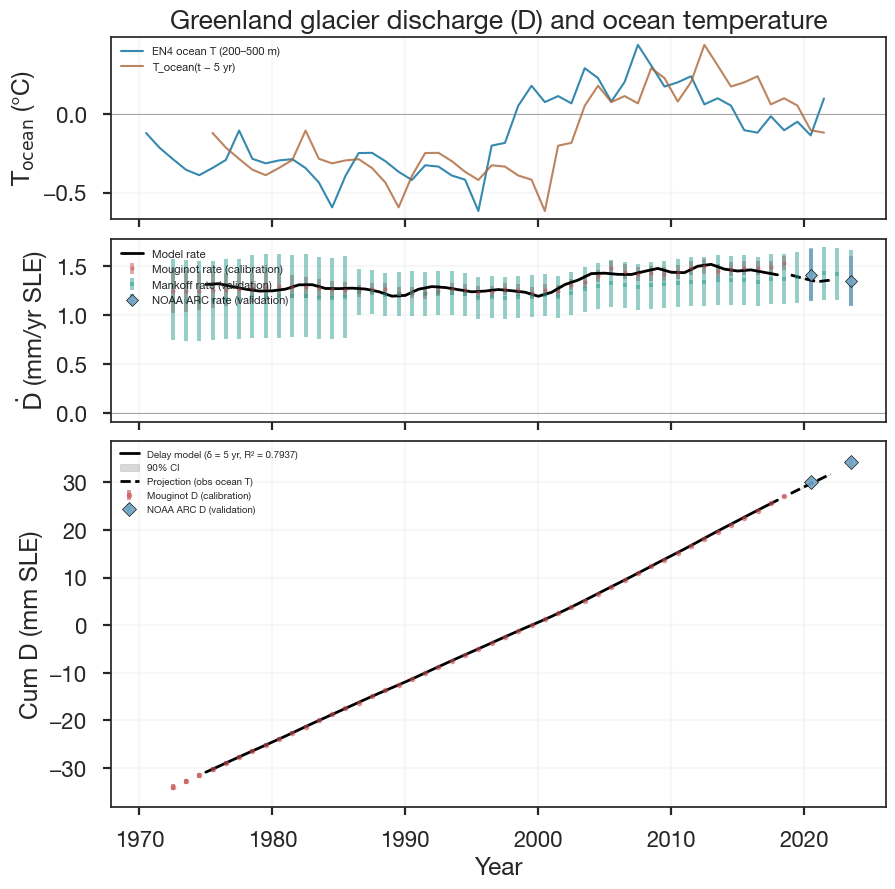

In [6]:
# ── Delay model fit diagnostic ──
# Panel (a): EN4 ocean T (annual + delayed)
# Panel (b): Discharge rate — observed (Mouginot + ARC) vs model
# Panel (c): Cumulative discharge fit + forward projection + ARC validation
if RERUN_FITS:
    # ── Single ensemble on unified time grid (calibration + projection) ──
    n_draw_diag = min(500, N_SAMPLES)
    rng_diag = np.random.default_rng(42)
    draw_idx = rng_diag.choice(N_SAMPLES, size=n_draw_diag, replace=False)

    diag_years = np.arange(np.floor(T_ocean_years[0]) + 1,
                           np.floor(T_ocean_years[-1]) + 2, 1.0)
    H_diag_ens = np.full((n_draw_diag, len(diag_years)), np.nan)

    for k in range(n_draw_diag):
        i = draw_idx[k]
        delta_i = result_discharge.delta_posterior[i]
        gamma_i = result_discharge.gamma_posterior[i]
        r0_i = result_discharge.r0_posterior[i]

        T_shifted = np.interp(diag_years, T_ocean_years + delta_i,
                              T_ocean_ann, left=np.nan, right=np.nan)
        valid = np.isfinite(T_shifted)
        if valid.sum() < 3:
            continue
        yrs_v = diag_years[valid]
        dt_v = np.diff(yrs_v, prepend=yrs_v[0] - 1)
        int_T = np.cumsum(T_shifted[valid] * dt_v)

        H_pred = (gamma_i * (int_T - result_discharge.int_T_mean_cal)
                  + r0_i * (yrs_v - result_discharge.t_mean_cal)
                  + result_discharge.H_mean_cal)

        H_diag_ens[k, valid] = H_pred

    diag_p5, diag_p50, diag_p95 = np.nanpercentile(
        H_diag_ens * M_TO_MM, [5, 50, 95], axis=0)

    # Model rate ensemble: dH/dt = γ·T_ocean(t-δ) + r₀ (in mm/yr)
    rate_diag_ens = np.full((n_draw_diag, len(diag_years)), np.nan)
    for k in range(n_draw_diag):
        i = draw_idx[k]
        delta_i = result_discharge.delta_posterior[i]
        gamma_i = result_discharge.gamma_posterior[i]
        r0_i = result_discharge.r0_posterior[i]
        T_shifted = np.interp(diag_years, T_ocean_years + delta_i,
                              T_ocean_ann, left=np.nan, right=np.nan)
        valid = np.isfinite(T_shifted)
        rate_diag_ens[k, valid] = (gamma_i * T_shifted[valid] + r0_i) * M_TO_MM

    rate_p5, rate_p50, rate_p95 = np.nanpercentile(
        rate_diag_ens, [5, 50, 95], axis=0)

    # Split into calibration and projection periods
    dyn_years_d = mou_comp['time_dyn']
    t_mou_end = dyn_years_d[-1]
    cal_mask = diag_years <= t_mou_end
    proj_mask = diag_years > t_mou_end

    # ── Mouginot observed rates ──
    mou_df = mou_comp['df']
    mou_yrs = mou_df['decimal_year'].values.astype(float)
    mou_drate = mou_df['discharge_rate'].values
    mou_drate_sig = mou_df['discharge_rate_sigma'].values
    bl_mask_mou = (mou_yrs >= 1995) & (mou_yrs <= 2005)
    mou_rate_mm = mou_drate * M_TO_MM
    mou_rate_sig_mm = mou_drate_sig * M_TO_MM

    # ── NOAA Arctic Report Card discharge validation ──
    arc_H_cum, arc_H_sig, arc_rate, arc_rate_sig = extend_with_arc(
        mou_comp, ARC_YEARS, ARC_D_GTYR, ARC_D_SIG,
        gt_to_m_sle=GT_TO_M_SLE,
    )
    arc_years_abs = ARC_YEARS
    arc_rate_mm = arc_rate * M_TO_MM
    arc_rate_sig_mm = arc_rate_sig * M_TO_MM

    # ══════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True,
                              gridspec_kw={'height_ratios': [1, 1, 2], 'hspace': 0.08})

    # ── Panel (a): EN4 ocean temperature ──
    ax = axes[0]
    delta_best = result_discharge.delta_best
    T_delayed_best = np.interp(T_ocean_years, T_ocean_years + delta_best,
                                T_ocean_ann, left=np.nan, right=np.nan)
    ax.plot(T_ocean_years, T_ocean_ann, 'C0-', lw=1.5, alpha=0.8,
            label='EN4 ocean T (200–500 m)')
    ax.plot(T_ocean_years, T_delayed_best, 'C1-', lw=1.5, alpha=0.8,
            label=f'T_ocean(t − {delta_best:.0f} yr)')
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    ax.set_ylabel('$\\text{T}_{\\text{ocean}}$ (°C)')
    ax.set_title('Greenland glacier discharge (D) and ocean temperature')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

    # ── Mankoff observed rates (validation, post-Mouginot) ──
    mk_df = mankoff_comp['df']
    mk_yrs = mk_df['decimal_year'].values.astype(float)
    mk_drate = mk_df['discharge_rate'].values
    mk_drate_sig = mk_df['discharge_rate_sigma'].values
    mk_rate_mm = mk_drate * M_TO_MM
    mk_rate_sig_mm = mk_drate_sig * M_TO_MM
    # ── Panel (b): Discharge rate ──
    ax = axes[1]
    ax.errorbar(mou_yrs, mou_rate_mm, yerr=2 * mou_rate_sig_mm,
                fmt='o', ms=3, color='C3', alpha=0.5, label='Mouginot rate (calibration)')
    ax.errorbar(mk_yrs, mk_rate_mm, yerr=2 * mk_rate_sig_mm,
                fmt='s', ms=3, color='C2', alpha=0.5, label='Mankoff rate (validation)')
    ax.errorbar(arc_years_abs, arc_rate_mm, yerr=2 * arc_rate_sig_mm,
                fmt='D', ms=6, color='C4', alpha=0.9, markeredgecolor='k',
                markeredgewidth=0.5, label='NOAA ARC rate (validation)')
    ax.plot(diag_years[cal_mask], rate_p50[cal_mask], 'k-', lw=2, label='Model rate')
    ax.fill_between(diag_years[cal_mask], rate_p5[cal_mask], rate_p95[cal_mask],
                    color='k', alpha=0.15)
    if proj_mask.any():
        ax.plot(diag_years[proj_mask], rate_p50[proj_mask], 'k--', lw=2)
        ax.fill_between(diag_years[proj_mask], rate_p5[proj_mask],
                        rate_p95[proj_mask], color='k', alpha=0.08)
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    ax.set_ylabel('$\\dot{\\text{D}}$ (mm/yr SLE)')
    #ax.set_title('(b) Discharge rate')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

    # ── Panel (c): Cumulative discharge fit + projection ──
    ax = axes[2]
    ax.errorbar(dyn_years_d, mou_comp['H_dyn'] * M_TO_MM,
                yerr=2 * mou_comp['sigma_dyn'] * M_TO_MM,
                fmt='o', ms=4, color='C3', alpha=0.6, label='Mouginot D (calibration)')
    ax.errorbar(arc_years_abs, arc_H_cum * M_TO_MM,
                yerr=2 * arc_H_sig * M_TO_MM,
                fmt='D', ms=7, color='C4', alpha=0.9, markeredgecolor='k',
                markeredgewidth=0.5, label='NOAA ARC D (validation)')

    ax.plot(diag_years[cal_mask], diag_p50[cal_mask], 'k-', lw=2,
            label=f'Delay model (δ = {delta_best:.0f} yr, '
                  f'R² = {result_discharge.r2_dyn:.4f})')
    ax.fill_between(diag_years[cal_mask], diag_p5[cal_mask], diag_p95[cal_mask],
                    color='k', alpha=0.15, label='90% CI')
    if proj_mask.any():
        ax.plot(diag_years[proj_mask], diag_p50[proj_mask], 'k--', lw=2,
                label='Projection (obs ocean T)')
        ax.fill_between(diag_years[proj_mask], diag_p5[proj_mask],
                        diag_p95[proj_mask], color='k', alpha=0.08)

    ax.set_ylabel('Cum D (mm SLE)')
    ax.set_xlabel('Year')
    #ax.set_title(f'(c) Discharge fit (RATE_CONSTRAINT_WEIGHT = {RATE_CONSTRAINT_WEIGHT})')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.2)

    plt.savefig(f'{FIG_DIR}/component_greenland_discharge_delay_fit.png',
                dpi=150, bbox_inches='tight')
    plt.show()


else:
    print('Skipping delay model fit diagnostic (RERUN_FITS = False)')


## 3. Diagnostics & Validation

### 3a. Discharge model posteriors and fit quality
### 3b. SMB observations vs GRACE − D implied SMB

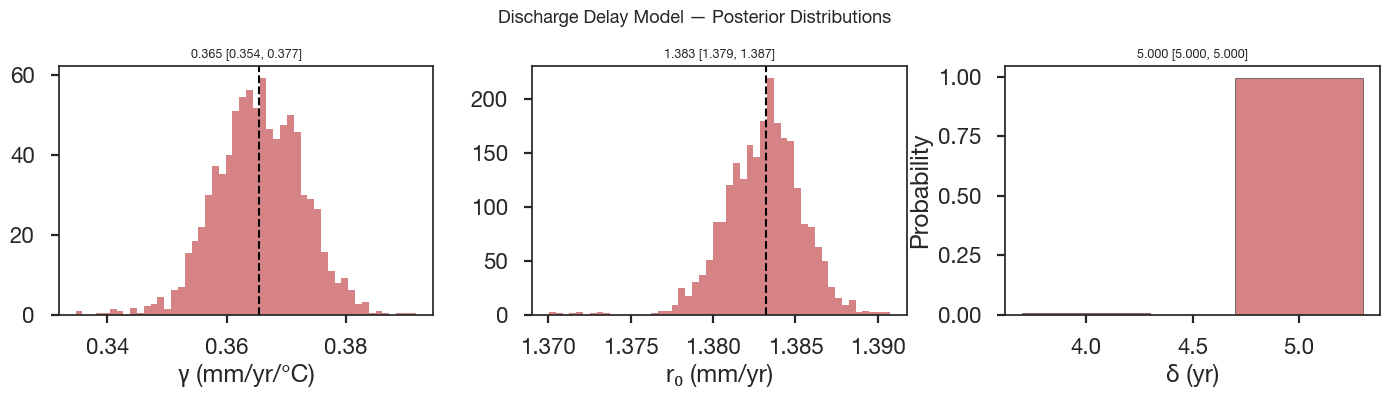

In [7]:
# ── Discharge model posteriors ──
# Three-panel histogram of the delay model parameters.
# γ is the ocean thermal forcing sensitivity, r₀ is the background rate,
# δ is the time delay (discrete, BIC-weighted mixture).
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

params = [
    (result_discharge.gamma_posterior * M_TO_MM, 'γ (mm/yr/°C)'),
    (result_discharge.r0_posterior * M_TO_MM, 'r₀ (mm/yr)'),
    (result_discharge.delta_posterior, 'δ (yr)'),
]

for ax, (vals, label) in zip(axes, params):
    if label.startswith('δ'):
        # Discrete: bar chart of delta values
        unique_d, counts = np.unique(vals, return_counts=True)
        ax.bar(unique_d, counts / len(vals), width=0.6,
               color='C3', alpha=0.7, edgecolor='k')
        ax.set_ylabel('Probability')
    else:
        ax.hist(vals, bins=50, density=True, alpha=0.7, color='C3')
        ax.axvline(np.median(vals), color='k', ls='--', lw=1.5)
    p5, p95 = np.percentile(vals, [5, 95])
    ax.set_xlabel(label)
    ax.set_title(f'{np.median(vals):.3f} [{p5:.3f}, {p95:.3f}]', fontsize=9)

plt.suptitle('Discharge Delay Model — Posterior Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_discharge_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


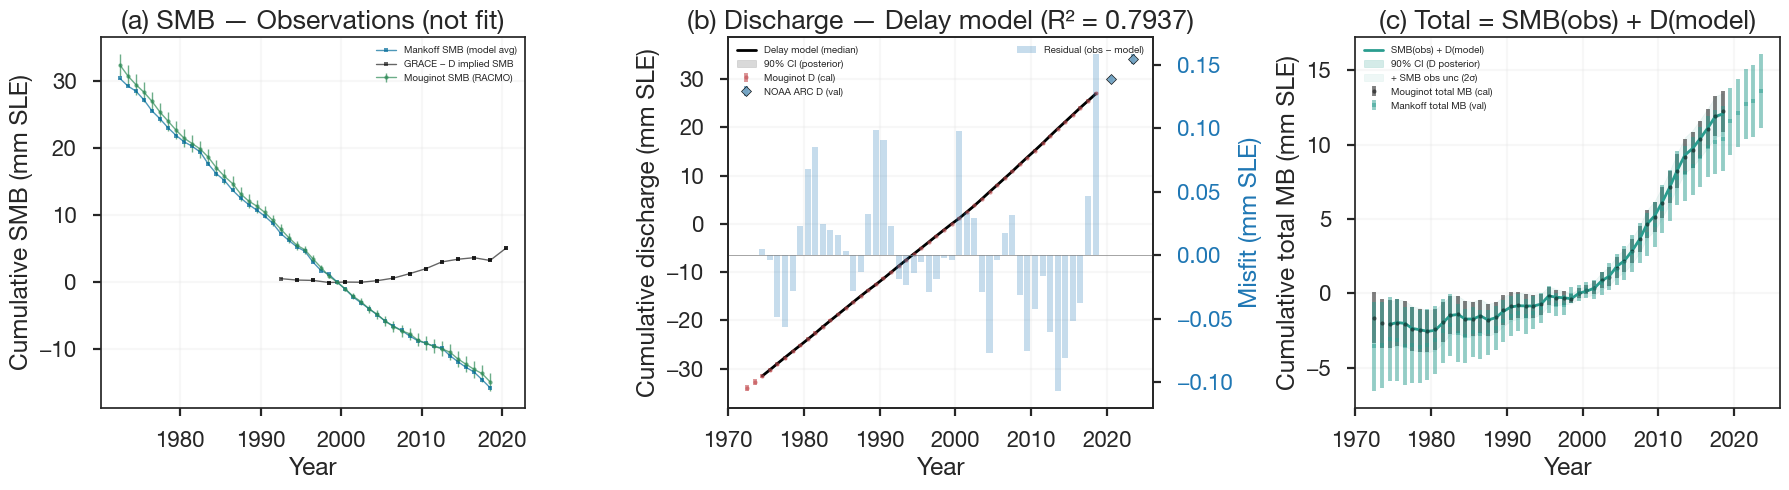

In [8]:
# ── Three-panel diagnostic: SMB, Discharge, and Total mass balance ──
# (a) SMB observations only — not calibrated, passed through as RACMO data
# (b) Discharge delay model fit against Mouginot D, forced by EN4 subsurface ocean T
# (c) Total = SMB(obs) + D(model), validated against Mouginot total MB

# ── Build discharge model ensemble from posterior samples ──
# Propagate (γ, r₀, δ) through the delay model forward equation
n_post = len(result_discharge.gamma_posterior)
n_draw = min(500, n_post)
rng_diag = np.random.default_rng(42)
draw_idx = rng_diag.choice(n_post, size=n_draw, replace=n_draw > n_post)

# Annualize ocean T (may already exist from cell 7, but recompute for safety)
year_floor_oc = np.floor(time_ocean_monthly).astype(int)
unique_years_oc = np.unique(year_floor_oc)
T_oc_annual = np.array([T_ocean_monthly[year_floor_oc == yr].mean()
                         for yr in unique_years_oc])
time_oc_annual = unique_years_oc.astype(float) + 0.5

H_dyn_ens = np.zeros((n_draw, len(mou_comp['time_dyn'])))
dyn_years_d = mou_comp['time_dyn']

for k in range(n_draw):
    i = draw_idx[k]
    delta_i = result_discharge.delta_posterior[i]
    gamma_i = result_discharge.gamma_posterior[i]
    r0_i = result_discharge.r0_posterior[i]

    T_shifted = np.interp(dyn_years_d, time_oc_annual + delta_i, T_oc_annual,
                          left=np.nan, right=np.nan)
    valid = np.isfinite(T_shifted)
    yrs_v = dyn_years_d[valid]
    dt_v = np.diff(yrs_v, prepend=yrs_v[0] - 1)
    int_T = np.cumsum(T_shifted[valid] * dt_v)

    # Un-demean using calibration-period means
    H_pred = (gamma_i * (int_T - result_discharge.int_T_mean_cal)
              + r0_i * (yrs_v - result_discharge.t_mean_cal)
              + result_discharge.H_mean_cal)
    H_dyn_ens[k, valid] = H_pred
    H_dyn_ens[k, ~valid] = np.nan

dyn_p5, dyn_p50, dyn_p95 = np.nanpercentile(H_dyn_ens * M_TO_MM, [5, 50, 95], axis=0)

# ── NOAA Arctic Report Card discharge validation (post-Mouginot) ──
mou_df_13 = mou_comp['df']
mou_yrs_13 = mou_df_13['decimal_year'].values.astype(float)
arc_H_13, arc_Hsig_13, _, _ = extend_with_arc(
    mou_comp, ARC_YEARS, ARC_D_GTYR, ARC_D_SIG,
    gt_to_m_sle=GT_TO_M_SLE,
)
arc_years_13 = ARC_YEARS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: SMB (observations only — not fit)
ax = axes[0]
ax.errorbar(mou_comp['time_smb'], mou_comp['H_smb'] * M_TO_MM,
            yerr=2 * mou_comp['sigma_smb'] * M_TO_MM,
            fmt='o-', ms=3, lw=1, color=COMP_COLORS['Greenland'], alpha=0.7,
            label='Mouginot SMB (RACMO)')

# Overlay Mankoff (2021) SMB — average of three RCMs (HIRHAM, MAR, RACMO)
# Mankoff SMB is mass-gain convention (positive = ice gains mass);
# negate to get SLR convention, then apply same cumulate logic as Mouginot.
mankoff_smb_path = f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv'
df_mankoff = pd.read_csv(mankoff_smb_path)
mank_time = df_mankoff['time'].values.astype(float) + 0.5  # mid-year
mank_smb_rate = -df_mankoff['SMB'].values * GT_TO_M_SLE    # negate: mass-gain → SLR
# Integrate full rate, rebase level to baseline year
mank_smb_cumul = np.cumsum(mank_smb_rate)  # dt=1 yr
bl_mank_idx = np.argmin(np.abs(mank_time - BASELINE_YEAR))
mank_smb_cumul -= mank_smb_cumul[bl_mank_idx]
# Trim to Mouginot era for visual comparison
mank_mask = (mank_time >= mou_comp['time_smb'][0]) & (mank_time <= mou_comp['time_smb'][-1])
ax.plot(mank_time[mank_mask], mank_smb_cumul[mank_mask] * M_TO_MM,
        's-', ms=3, lw=1, color='C0', alpha=0.7,
        label='Mankoff SMB (model avg)')

# Overlay GRACE − D implied SMB as RCM-independent validation
if os.path.exists(grace_d_path):
    df_gd = pd.read_csv(grace_d_path)
    gd_years = df_gd['year'].values
    gd_rate = df_gd['implied_smb_rate_slr'].values
    bl_mask_gd = (gd_years >= 1995) & (gd_years <= 2005)
    if bl_mask_gd.sum() > 0:
        gd_rate_anom = gd_rate - gd_rate[bl_mask_gd].mean()
    else:
        gd_rate_anom = gd_rate
    dt_gd = np.diff(gd_years, prepend=gd_years[0] - 1)
    gd_cumul = np.cumsum(gd_rate_anom * dt_gd)
    bl_gd = np.argmin(np.abs(gd_years - BASELINE_YEAR))
    gd_cumul -= gd_cumul[bl_gd]
    ax.plot(gd_years, gd_cumul * M_TO_MM, 'ks-', ms=3, lw=1, alpha=0.6,
            label='GRACE − D implied SMB')

ax.set_ylabel('Cumulative SMB (mm SLE)')
ax.set_xlabel('Year')
ax.set_title('(a) SMB — Observations (not fit)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# Panel B: Discharge (delay model) with posterior uncertainty
ax = axes[1]
ax.errorbar(mou_comp['time_dyn'], mou_comp['H_dyn'] * M_TO_MM,
            yerr=2 * mou_comp['sigma_dyn'] * M_TO_MM,
            fmt='o', ms=3, color='C3', alpha=0.6, label='Mouginot D (cal)')
ax.errorbar(arc_years_13, arc_H_13 * M_TO_MM,
            yerr=2 * arc_Hsig_13 * M_TO_MM,
            fmt='D', ms=5, color='C4', alpha=0.9, markeredgecolor='k',
            markeredgewidth=0.5, label='NOAA ARC D (val)')
ax.plot(mou_comp['time_dyn'], dyn_p50, 'k-', lw=2, label='Delay model (median)')
ax.fill_between(mou_comp['time_dyn'], dyn_p5, dyn_p95,
                color='k', alpha=0.15, label='90% CI (posterior)')
ax.set_ylabel('Cumulative discharge (mm SLE)')
ax.set_xlabel('Year')
ax.set_title(f'(b) Discharge — Delay model (R² = {result_discharge.r2_dyn:.4f})')
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.2)

# Right-hand axis: misfit (obs − model median)
ax2 = ax.twinx()
resid_dyn = (mou_comp['H_dyn'] * M_TO_MM) - dyn_p50
ax2.bar(mou_comp['time_dyn'], resid_dyn, width=0.8, color='tab:blue', alpha=0.25,
        label='Residual (obs − model)')
ax2.axhline(0, color='gray', ls='-', lw=0.5)
ax2.set_ylabel('Misfit (mm SLE)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(fontsize=7, loc='upper right')

# Panel C: Total = observed SMB + modeled discharge, with combined uncertainties
ax = axes[2]
ax.errorbar(mou_comp['time_mb'], mou_comp['H_mb'] * M_TO_MM,
            yerr=2 * mou_comp['sigma_mb'] * M_TO_MM,
            fmt='o', ms=3, color='k', alpha=0.5, label='Mouginot total MB (cal)')

# Mankoff total MB — withheld independent validation dataset
ax.errorbar(mankoff_comp['time_mb'], mankoff_comp['H_mb'] * M_TO_MM,
            yerr=2 * mankoff_comp['sigma_mb'] * M_TO_MM,
            fmt='s', ms=3, color='C2', alpha=0.5, label='Mankoff total MB (val)')

smb_on_dyn = np.interp(mou_comp['time_dyn'], mou_comp['time_smb'], mou_comp['H_smb'])
smb_sig_on_dyn = np.interp(mou_comp['time_dyn'], mou_comp['time_smb'], mou_comp['sigma_smb'])
total_ens = smb_on_dyn[np.newaxis, :] + H_dyn_ens
tot_p5, tot_p50, tot_p95 = np.nanpercentile(total_ens * M_TO_MM, [5, 50, 95], axis=0)
smb_2sig_mm = 2 * smb_sig_on_dyn * M_TO_MM
tot_p5_full = tot_p5 - smb_2sig_mm
tot_p95_full = tot_p95 + smb_2sig_mm

ax.plot(mou_comp['time_dyn'], tot_p50, 'C2-', lw=2, label='SMB(obs) + D(model)')
ax.fill_between(mou_comp['time_dyn'], tot_p5, tot_p95,
                color='C2', alpha=0.20, label='90% CI (D posterior)')
ax.fill_between(mou_comp['time_dyn'], tot_p5_full, tot_p95_full,
                color='C2', alpha=0.08, label='+ SMB obs unc (2σ)')
ax.set_ylabel('Cumulative total MB (mm SLE)')
ax.set_xlabel('Year')
ax.set_title('(c) Total = SMB(obs) + D(model)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_smb_d_fit.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Projections

**SMB projections:** RCM-derived C_T with inter-RCM structural uncertainty
(C_T = −300 ± 80 Gt/yr/°C GMST, quadratic −50 ± 30 Gt/yr/°C²).
Propagated through MC ensemble via `project_smb_ensemble()`.

**Discharge projections:** Calibrated ODE with projected ocean T from the
surface-to-ocean transfer function. Parametric uncertainty from discharge
posterior (γ, r₀, δ) + transfer function uncertainty (α, β, σ_resid).

**Total:** H_GrIS = H_SMB + H_D, with SMB and D uncertainty combined in
quadrature (independent components).

In [9]:
# ── SSP constants (always needed for downstream plotting) ──
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
PROJ_YEARS = np.arange(1950, 2151, dtype=float)
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}

if RERUN_FITS:
    # ── Load and rebaseline SSP temperature scenarios ──
    # Splice CMIP6 historical + SSP, align to Berkeley Earth observational baseline
    df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
    overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
    hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
    temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
    offset_gmst = hist_bl - temp_bl  # CMIP6 → Berkeley Earth offset

    temp_projections = {}
    proj_monthly_temps = {}
    proj_monthly_times = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset_gmst
        temp_projections[ssp_name] = combined
        # Interpolate to monthly for integration
        t_mon = np.arange(combined['decimal_year'].min(),
                           combined['decimal_year'].max(), 1/12)
        T_mon = np.interp(t_mon, combined['decimal_year'].values,
                           combined['temperature'].values)
        # Splice: observed before cutoff, projected after
        T_full = np.concatenate([temp_monthly, T_mon[t_mon > temp_time_monthly[-1]]])
        t_full = np.concatenate([temp_time_monthly, t_mon[t_mon > temp_time_monthly[-1]]])
        proj_monthly_temps[ssp_name] = T_full
        proj_monthly_times[ssp_name] = t_full

    # ═══════════════════════════════════════════════════════════════
    # SMB projections: ΔḢ_smb = C_T·ΔT + C_T²·ΔT²
    # Uses RCM-derived C_T with inter-RCM structural uncertainty.
    # ═══════════════════════════════════════════════════════════════
    print('Projecting SMB (RCM-derived C_T)...')
    T_proj_annual = {}
    for ssp in PROJ_SSPS:
        df_t = temp_projections[ssp]
        T_proj_annual[ssp] = np.interp(PROJ_YEARS, df_t['decimal_year'].values,
                                        df_t['temperature'].values)

    smb_projections = project_smb_ensemble(
        sensitivity=GREENLAND_SMB,
        T_proj=T_proj_annual,
        time_proj=PROJ_YEARS,
        T_baseline=0.0,  # anomalies relative to 1995–2005
        n_samples=N_SAMPLES,
        seed=600,
        baseline_year=BASELINE_YEAR,
    )

    # ── Splice observed SMB for the calibration period ──
    obs_smb_yr = mou_comp['time_smb']
    obs_smb_H = mou_comp['H_smb']
    obs_smb_sig = mou_comp['sigma_smb']

    bl_obs_idx = np.argmin(np.abs(obs_smb_yr - BASELINE_YEAR))
    obs_smb_H_rb = obs_smb_H - obs_smb_H[bl_obs_idx]
    obs_on_grid = np.interp(PROJ_YEARS, obs_smb_yr, obs_smb_H_rb,
                            left=np.nan, right=np.nan)
    sig_on_grid = np.interp(PROJ_YEARS, obs_smb_yr, obs_smb_sig,
                            left=np.nan, right=np.nan)
    obs_mask = ~np.isnan(obs_on_grid)

    splice_idx = np.max(np.where(obs_mask)[0])
    splice_year = PROJ_YEARS[splice_idx]

    # Pre-draw observation noise once so all SSPs get identical
    # pre-splice samples (observation period is SSP-independent).
    rng_splice = np.random.default_rng(seed=601)
    obs_noise = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for t_idx in np.where(obs_mask)[0]:
        obs_noise[:, t_idx] = obs_on_grid[t_idx] + rng_splice.normal(
            0, sig_on_grid[t_idx], N_SAMPLES)

    for ssp in PROJ_SSPS:
        ct_samples = smb_projections[ssp]['samples']
        spliced = ct_samples.copy()
        spliced[:, obs_mask] = obs_noise[:, obs_mask]

        obs_at_splice = obs_on_grid[splice_idx]
        ct_at_splice = ct_samples[:, splice_idx]
        shift = obs_at_splice - ct_at_splice
        future_mask = PROJ_YEARS > splice_year
        spliced[:, future_mask] = (ct_samples[:, future_mask]
                                   + shift[:, None])

        smb_projections[ssp] = {
            'samples': spliced,
            'median': np.median(spliced, axis=0),
            'p5': np.percentile(spliced, 5, axis=0),
            'p17': np.percentile(spliced, 17, axis=0),
            'p83': np.percentile(spliced, 83, axis=0),
            'p95': np.percentile(spliced, 95, axis=0),
            'rate_median': smb_projections[ssp]['rate_median'],
        }

    print(f'  Spliced SMB observations up to {splice_year:.0f}')
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = smb_projections[ssp]['median'][idx_2100] * M_TO_MM
        lo = smb_projections[ssp]['p5'][idx_2100] * M_TO_MM
        hi = smb_projections[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} SMB at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ═══════════════════════════════════════════════════════════════
    # Discharge projections: delay model with ocean T transfer
    # For each MC sample: draw posterior (γ, r₀, δ) + transfer (α, β),
    # shift ocean T by delta, integrate, and un-demean.
    # ═══════════════════════════════════════════════════════════════
    print('\nProjecting discharge (delay model + ocean T transfer)...')
    discharge_projections = {}
    rng_dyn = np.random.default_rng(700)

    # Transfer function uncertainty propagated per MC sample.
    # Drawn once and shared across SSPs intentionally: sample i represents
    # the same physical 'world' (same ocean transfer function) under all
    # emissions pathways, ensuring inter-SSP differences reflect only
    # the forcing, not parameter uncertainty.
    alpha_draws = rng_dyn.normal(ocean_transfer['alpha'],
                                 ocean_transfer['alpha_se'], size=N_SAMPLES)
    beta_draws = rng_dyn.normal(ocean_transfer['beta'],
                                ocean_transfer['beta_se'], size=N_SAMPLES)
    AA_draws = rng_dyn.normal(AA, AA_SIGMA, size=N_SAMPLES)

    for ssp in PROJ_SSPS:
        T_mon = proj_monthly_temps[ssp]
        t_mon = proj_monthly_times[ssp]

        # Convert GMST → Greenland surface T via Arctic amplification
        T_gr_proj = T_mon * AA
        ssp_start_idx = min(np.searchsorted(t_mon, temp_time_monthly[-1]), len(t_mon) - 1)
        ssp_start = t_mon[ssp_start_idx]

        # Splice observed Greenland T (historical) + projected
        hist_mask_gr = gr_time_monthly < ssp_start
        ssp_mask = t_mon >= ssp_start
        t_full_gr = np.concatenate([gr_time_monthly[hist_mask_gr], t_mon[ssp_mask]])
        T_full_gr = np.concatenate([gr_temp_monthly[hist_mask_gr], T_gr_proj[ssp_mask]])

        # Historical ocean T for splicing
        hist_mask_oc = time_ocean_monthly < ssp_start
        oc_hist_t = time_ocean_monthly[hist_mask_oc]
        oc_hist_T = T_ocean_monthly[hist_mask_oc]

        ens_dyn = np.zeros((N_SAMPLES, len(PROJ_YEARS)))

        for i in range(N_SAMPLES):
            delta_i = result_discharge.delta_posterior[i]
            gamma_i = result_discharge.gamma_posterior[i]
            r0_i = result_discharge.r0_posterior[i]

            # Project ocean T from surface T via transfer function
            T_ocean_proj = alpha_draws[i] * (T_mon[ssp_mask] * AA_draws[i]) + beta_draws[i]
            t_oc_full = np.concatenate([oc_hist_t, t_mon[ssp_mask]])
            T_oc_full = np.concatenate([oc_hist_T, T_ocean_proj])

            # Annualize the full ocean T series
            yr_floor = np.floor(t_oc_full).astype(int)
            unique_yrs = np.unique(yr_floor)
            T_oc_ann_proj = np.array([T_oc_full[yr_floor == yr].mean()
                                      for yr in unique_yrs])
            t_oc_ann_proj = unique_yrs.astype(float) + 0.5

            # Shift by delta: T_delayed = T_ocean(t - delta)
            T_delayed = np.interp(PROJ_YEARS, t_oc_ann_proj + delta_i,
                                  T_oc_ann_proj, left=np.nan, right=np.nan)

            # Fill any leading NaNs with zero (before ocean data starts)
            nan_mask = np.isnan(T_delayed)
            T_delayed[nan_mask] = 0.0

            # Cumulative integral
            dt_proj = np.diff(PROJ_YEARS, prepend=PROJ_YEARS[0] - 1)
            int_T_delayed = np.cumsum(T_delayed * dt_proj)

            # Un-demean: H_dyn = γ·(∫T - mean_cal) + r₀·(t - mean_t_cal) + H_mean_cal
            H_dyn_i = (gamma_i * (int_T_delayed - result_discharge.int_T_mean_cal)
                       + r0_i * (PROJ_YEARS - result_discharge.t_mean_cal)
                       + result_discharge.H_mean_cal)

            # Rebase to BASELINE_YEAR
            bl_idx = np.argmin(np.abs(PROJ_YEARS - BASELINE_YEAR))
            ens_dyn[i] = H_dyn_i - H_dyn_i[bl_idx]

        discharge_projections[ssp] = {
            'samples': ens_dyn,
            'median': np.median(ens_dyn, axis=0),
            'p5': np.percentile(ens_dyn, 5, axis=0),
            'p17': np.percentile(ens_dyn, 17, axis=0),
            'p83': np.percentile(ens_dyn, 83, axis=0),
            'p95': np.percentile(ens_dyn, 95, axis=0),
        }

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        med = discharge_projections[ssp]['median'][idx_2100] * M_TO_MM
        lo = discharge_projections[ssp]['p5'][idx_2100] * M_TO_MM
        hi = discharge_projections[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} D at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ═══════════════════════════════════════════════════════════════
    # Total Greenland = SMB + Discharge (independent, additive)
    # ═══════════════════════════════════════════════════════════════
    print('\nTotal Greenland (SMB + D):')
    greenland_proj = {}
    for ssp in PROJ_SSPS:
        total_samples = smb_projections[ssp]['samples'] + discharge_projections[ssp]['samples']
        greenland_proj[ssp] = {
            'samples': total_samples,
            'median': np.median(total_samples, axis=0),
            'p5': np.percentile(total_samples, 5, axis=0),
            'p17': np.percentile(total_samples, 17, axis=0),
            'p83': np.percentile(total_samples, 83, axis=0),
            'p95': np.percentile(total_samples, 95, axis=0),
            'smb_median': smb_projections[ssp]['median'],
            'dyn_median': discharge_projections[ssp]['median'],
        }

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        med = greenland_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = greenland_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = greenland_proj[ssp]['p95'][idx_2100] * M_TO_MM
        smb_med = smb_projections[ssp]['median'][idx_2100] * M_TO_MM
        dyn_med = discharge_projections[ssp]['median'][idx_2100] * M_TO_MM
        print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm '
              f'(SMB: {smb_med:.0f}, D: {dyn_med:.0f})')

    # ── Persist posteriors + projections to HDF5 ──
    save_greenland(
        result_discharge=result_discharge,
        smb_sensitivity=GREENLAND_SMB,
        ocean_transfer=ocean_transfer,
        obs_smb_years=mou_comp['time_smb'],
        obs_smb_H=mou_comp['H_smb'],
        obs_smb_sigma=mou_comp['sigma_smb'],
        obs_dyn_years=mou_comp['time_dyn'],
        obs_dyn_H=mou_comp['H_dyn'],
        obs_dyn_sigma=mou_comp['sigma_dyn'],
        greenland_proj=greenland_proj,
        smb_projections=smb_projections,
        discharge_projections=discharge_projections,
        h5_path=RESULTS_H5,
    )

    # ── Save discharge diagnostic data (after save_greenland so it persists) ──
    with h5py.File(RESULTS_H5, 'a') as _hf:
        if 'greenland/discharge_diagnostic' in _hf:
            del _hf['greenland/discharge_diagnostic']
        _fg = _hf.create_group('greenland/discharge_diagnostic')
        _fg.create_dataset('cal_years', data=dyn_years_d)
        _fg.create_dataset('cal_H_mm', data=mou_comp['H_dyn'] * M_TO_MM)
        _fg.create_dataset('cal_sigma_mm', data=mou_comp['sigma_dyn'] * M_TO_MM)
        _fg.create_dataset('arc_years', data=arc_years_abs)
        _fg.create_dataset('arc_H_cum_mm', data=arc_H_cum * M_TO_MM)
        _fg.create_dataset('arc_H_sig_mm', data=arc_H_sig * M_TO_MM)
        _fg.create_dataset('diag_years', data=diag_years)
        _fg.create_dataset('diag_p5', data=diag_p5)
        _fg.create_dataset('diag_p50', data=diag_p50)
        _fg.create_dataset('diag_p95', data=diag_p95)
        _fg.create_dataset('cal_mask', data=cal_mask)
        _fg.create_dataset('proj_mask', data=proj_mask)
        _fg.attrs['delta_best'] = result_discharge.delta_best
        _fg.attrs['r2_dyn'] = result_discharge.r2_dyn
    print('Discharge diagnostic saved to component_results.h5')

else:
    # ── Load cached projections from HDF5 (fast path) ──
    cached = load_component('greenland', h5_path=RESULTS_H5)
    greenland_proj = cached['projections']
    smb_projections = cached.get('projections_smb', {})
    discharge_projections = cached.get('projections_discharge', {})

    # Still need SSP temperatures for downstream plotting cells
    df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
    overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
    hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
    temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
    offset_gmst = hist_bl - temp_bl

    temp_projections = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset_gmst
        temp_projections[ssp_name] = combined

    print('Loaded cached Greenland projections from HDF5')
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        if ssp in greenland_proj:
            med = greenland_proj[ssp]['median'][idx_2100] * M_TO_MM
            lo = greenland_proj[ssp]['p5'][idx_2100] * M_TO_MM
            hi = greenland_proj[ssp]['p95'][idx_2100] * M_TO_MM
            print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Projecting SMB (RCM-derived C_T)...
  Spliced SMB observations up to 2018
  SSP1-2.6 SMB at 2100: -27 [-56, 3] mm
  SSP2-4.5 SMB at 2100: 16 [-31, 61] mm
  SSP3-7.0 SMB at 2100: 60 [-4, 124] mm
  SSP5-8.5 SMB at 2100: 109 [22, 196] mm

Projecting discharge (delay model + ocean T transfer)...


  SSP1-2.6 D at 2100: 149 [144, 154] mm


  SSP2-4.5 D at 2100: 153 [147, 161] mm


  SSP3-7.0 D at 2100: 158 [150, 167] mm


  SSP5-8.5 D at 2100: 162 [153, 173] mm

Total Greenland (SMB + D):
  SSP1-2.6: 122 [92, 152] mm (SMB: -27, D: 149)
  SSP2-4.5: 169 [122, 214] mm (SMB: 16, D: 153)
  SSP3-7.0: 219 [153, 283] mm (SMB: 60, D: 158)
  SSP5-8.5: 271 [183, 359] mm (SMB: 109, D: 162)


Saved greenland → ../data/processed/component_results.h5  (459019 KB total)
Discharge diagnostic saved to component_results.h5


/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:954: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


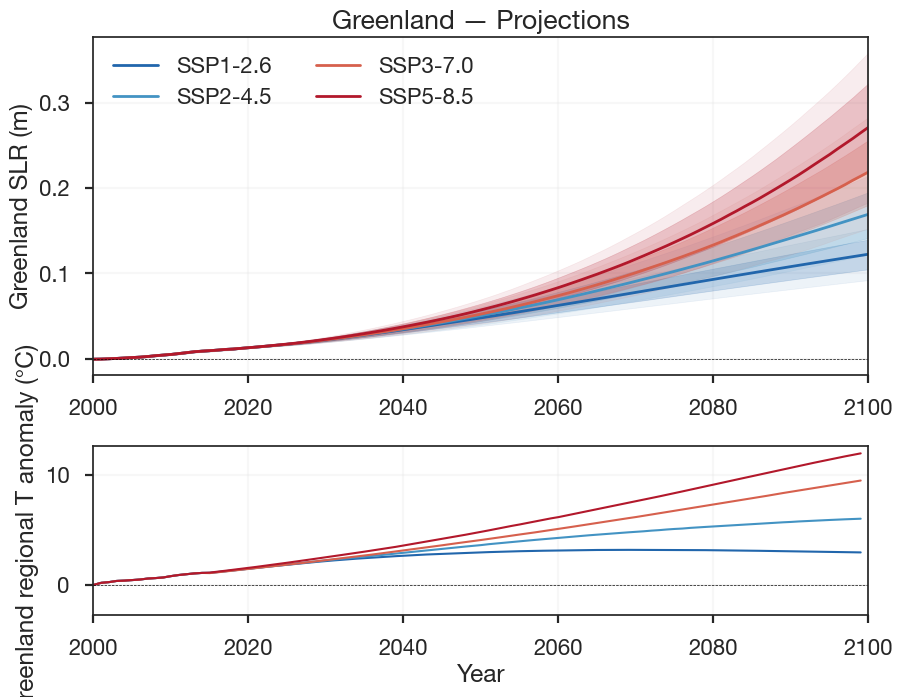

In [10]:
# ── Two-panel projection plot: SLR (top) + Greenland T scenarios (bottom) ──
# Lower panel shows Greenland regional T = GMST × AA to convey the local
# warming that drives both SMB and discharge.
temp_scenarios = {}
for ssp in PROJ_SSPS:
    df_t = temp_projections[ssp]
    ann = df_t.groupby(df_t['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp] = {
        'years': ann['decimal_year'].values,
        'temperature': ann['temperature'].values * AA,
    }

plot_component_projection_twopanel(
    comp_proj=greenland_proj, proj_years=PROJ_YEARS,
    component_name='Greenland',
    temperature_scenarios=temp_scenarios,
    temp_label='Greenland regional T anomaly (°C)',
    ssps=PROJ_SSPS,
    xlim=(2000,2100),
    save_path=f'{FIG_DIR}/component_greenland_twopanel.png',
)

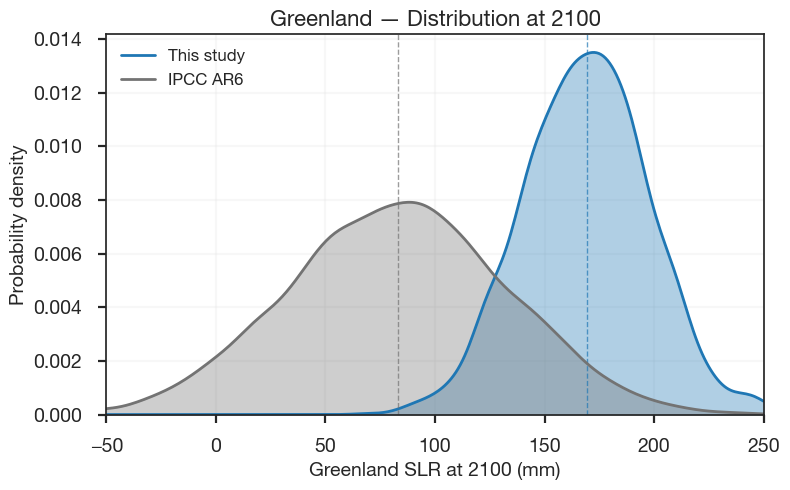

In [11]:
# ── Histogram comparison: this study vs IPCC AR6 at 2100 ──
# IPCC GIS component extracted from AR6 confidence output NetCDFs.
# IPCC percentiles are approximated as Gaussian for histogram overlay.
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'
rng_hist = np.random.default_rng(99)

our_samples = greenland_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', SSP_CODE[HIST_SSP], 'GIS')
sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if ipcc_data is not None:
    ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ex['years'] - 2100))
    ipcc_med = ex['q50'][yr_idx]
    ipcc_sig = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * Z_90)  # 90% CI → σ
    ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples)
    labels.append('IPCC AR6')
    colors.append('0.45')


plot_component_histogram(sample_sets, labels, colors, 'Greenland', year=2100, xlim=(-50,250),
                         fontsize={'title': 16, 'legend': 12, 'xlabel': 14, 'xtick': 14, 'ylabel': 14, 'ytick': 14},
                          save_path=f'{FIG_DIR}/component_greenland_histogram_2100.png')


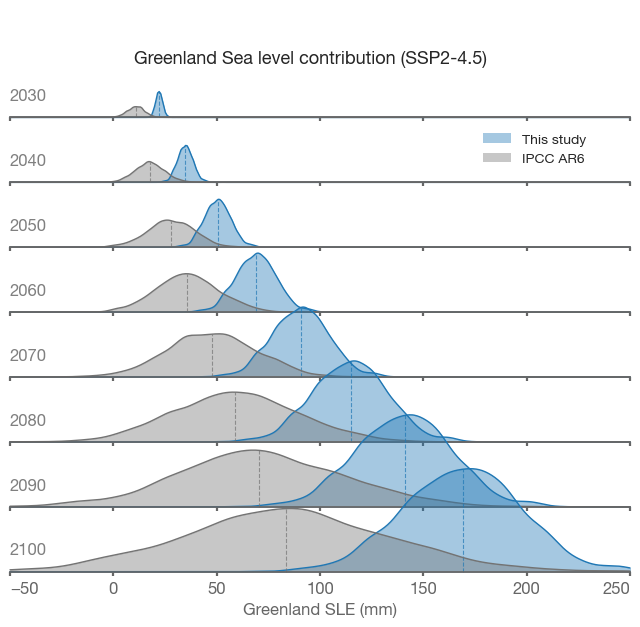

In [12]:
# ── Ridge plot: distribution evolution at decadal intervals (2030–2100) ──
# Shows how the predictive distribution widens over time and how
# our estimates diverge from IPCC AR6 at longer horizons.
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    # Pass samples in meters — plot_component_ridge handles unit conversion
    year_dict = {'This study': greenland_proj[RIDGE_SSP]['samples'][:, idx_yr]}
    if ipcc_data is not None:
        ex = ipcc_extract(ipcc_data)
        yr_idx_i = np.argmin(np.abs(ex['years'] - yr))
        if np.abs(ex['years'][yr_idx_i] - yr) < 5:
            ipcc_med_yr = ex['q50'][yr_idx_i]
            ipcc_sig_yr = (ex['q95'][yr_idx_i] - ex['q05'][yr_idx_i]) / (2 * Z_90)
            # IPCC extract returns mm — convert to meters for consistency
            year_dict['IPCC AR6'] = rng_ridge.normal(ipcc_med_yr, ipcc_sig_yr, N_SAMPLES) / M_TO_MM
    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'Greenland', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'IPCC AR6': '0.45'},
                      xlabel='Greenland SLE (mm)',
                      units='mm',
                      xlim=(-50,250),
                      top=1.05, legend_bbox=(0.95, -0.03),
                      fontsize={'year': 12, 'title': 13, 'legend': 10, 'xlabel': 12, 'xtick': 12},
                      title=f'Greenland Sea level contribution ({RIDGE_SSP})',
                      save_path=f'{FIG_DIR}/component_greenland_ridge.png')

## 5. IPCC Comparison & Hindcast

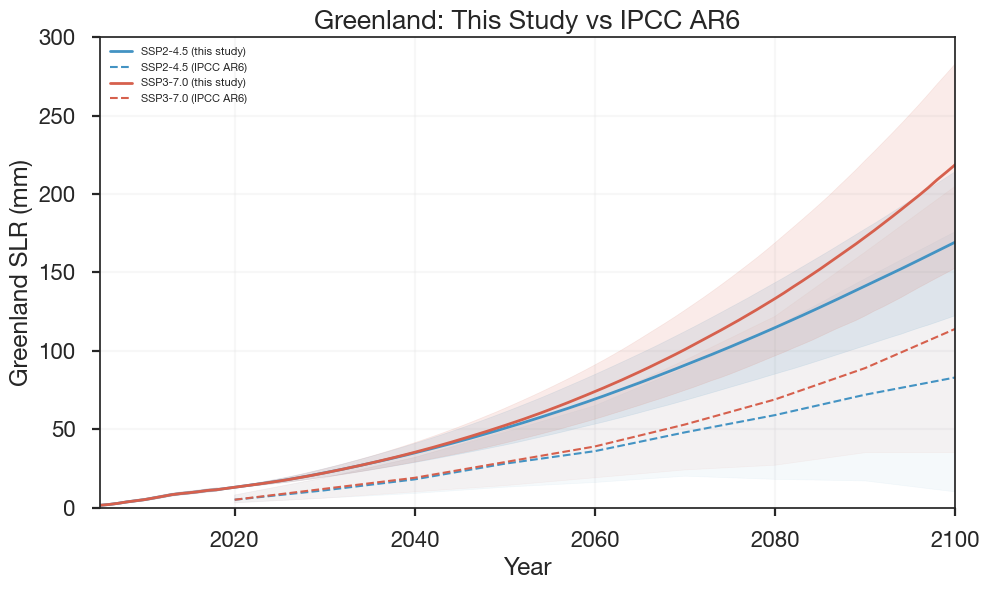

In [13]:
# ── Time-series comparison: this study vs IPCC AR6 GIS component ──
# Solid lines = this study (SMB + D), dashed = IPCC AR6 medium confidence.
# IPCC data in mm (native units from AR6 NetCDFs); our data in m → mm.

fig, ax = plt.subplots(figsize=(10, 6))
proj_mask = PROJ_YEARS >= 2000
yr_plot = PROJ_YEARS[proj_mask]

for ssp in ['SSP2-4.5', 'SSP3-7.0']:
    color = SSP_COLORS[ssp]
    p = greenland_proj[ssp]
    ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2, label=f'{ssp} (this study)')
    ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM, p['p95'][proj_mask] * M_TO_MM,
                    color=color, alpha=0.12)
    # IPCC AR6 overlay
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', SSP_CODE[ssp], 'GIS')
    if ipcc_comp is not None:
        ex = ipcc_extract(ipcc_comp)
        ax.plot(ex['years'], ex['q50'], color=color, ls='--', lw=1.5, label=f'{ssp} (IPCC AR6)')
        ax.fill_between(ex['years'], ex['q05'], ex['q95'], color=color, alpha=0.05)

ax.set_xlabel('Year')
ax.set_ylabel('Greenland SLR (mm)')
ax.set_title('Greenland: This Study vs IPCC AR6')
ax.legend(fontsize=8)
ax.set_xlim(2005, 2100)
ax.set_ylim(0,300)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_ipcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Appendix: Sensitivity 

In [14]:
# ── Sensitivity test: Greenland regional T vs GMST for total mass balance ──
# Fits a linear rate–temperature model (a=0, b·T + c) to Mouginot total MB
# using both Greenland regional T and GMST.  In level space, GMST tends to
# outperform regional T because GMST is smoother and correlates well with the
# secular cumulative trend; regional T has more interannual variability that
# acts as noise in the level-space fit.
from component_analysis import apply_sigma_taper, restrict_and_fit

df_mou = read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_year = df_mou['decimal_year'].values
mou_cumul = df_mou['cumulative_mb'].values  # m SLE, SLR convention

OBS_WINDOW = (1972, 2015)
mask_mou = (mou_year >= OBS_WINDOW[0]) & (mou_year <= OBS_WINDOW[1])
yrs_r = mou_year[mask_mou]
H_r = mou_cumul[mask_mou].copy()
bl_r = np.argmin(np.abs(yrs_r - BASELINE_YEAR))
H_r -= H_r[bl_r]  # rebaseline to BASELINE_YEAR (2000)
sig_r = df_mou['cumulative_mb_sigma'].values[mask_mou]

# Design vectors: I₁ = ∫T dt, I₀ = elapsed time
design_local = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly, time_monthly=gr_time_monthly, obs_times=yrs_r)
design_gmst = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly, obs_times=yrs_r)

# Linear-only fit (I₂ zeroed out to suppress quadratic term)
PRIOR_KW = dict(prior_scale_a=0.010, prior_scale_b=0.01,
                prior_c_mean=0.0003, prior_c_sigma=0.001,
                prior_sigma_extra_scale=0.005, prior_H0_sigma=0.005)

res_local = fit_bayesian_level(
    H_obs=H_r, sigma_obs=sig_r,
    I2_obs=np.zeros_like(design_local['I2_obs']),
    I1_obs=design_local['I1_obs'], I0_obs=design_local['I0_obs'],
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=800, **PRIOR_KW)
res_gmst = fit_bayesian_level(
    H_obs=H_r, sigma_obs=sig_r,
    I2_obs=np.zeros_like(design_gmst['I2_obs']),
    I1_obs=design_gmst['I1_obs'], I0_obs=design_gmst['I0_obs'],
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=900, **PRIOR_KW)

b_local = np.median(res_local.posterior_samples[:, 1]) * M_TO_MM
b_gmst = np.median(res_gmst.posterior_samples[:, 1]) * M_TO_MM

print(f'Greenland T: b={b_local:.3f} mm/yr/°C, R²={res_local.r2:.4f}')
print(f'GMST:        b={b_gmst:.3f} mm/yr/°C, R²={res_gmst.r2:.4f}')
better = 'Greenland T' if res_local.r2 > res_gmst.r2 else 'GMST'
print(f'\u2192 {better} provides better level-space fit (R\u00b2 = {max(res_local.r2, res_gmst.r2):.4f}).')


Bayesian level-space fit: n=43 observations, ndim=5
  Priors: a~Exp(mean=10.00 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.350, c=0.478 mm/yr, σ_extra=0.67 mm


  0%|          | 0/6000 [00:00<?, ?it/s]

  1%|▏         | 75/6000 [00:00<00:07, 749.72it/s]

  2%|▎         | 150/6000 [00:00<00:07, 741.36it/s]

  4%|▍         | 226/6000 [00:00<00:07, 745.73it/s]

...

 96%|█████████▌| 5773/6000 [00:07<00:00, 793.53it/s]

 98%|█████████▊| 5853/6000 [00:07<00:00, 791.74it/s]

 99%|█████████▉| 5933/6000 [00:07<00:00, 789.11it/s]

100%|██████████| 6000/6000 [00:07<00:00, 789.75it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.021  ESS_bulk=200  ESS_tail=383
    alpha0: R-hat=1.009  ESS_bulk=249  ESS_tail=429
    trend: R-hat=1.014  ESS_bulk=249  ESS_tail=777
    log_sigma_extra: R-hat=1.019  ESS_bulk=217  ESS_tail=357
    H0: R-hat=1.010  ESS_bulk=218  ESS_tail=405
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=10.154, b=0.591, c=0.310 mm/yr
  σ_extra: median=0.36 mm [0.05, 0.79]
  R² = 0.9030,  acceptance = 0.50
Greenland T: b=0.357 mm/yr/°C, R²=0.9568
GMST:        b=0.593 mm/yr/°C, R²=0.9030
→ Greenland T provides better level-space fit (R² = 0.9568).
